# Housing Dataset — Exploratory Data Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Dataset Overview

In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\Column names:')
print(df.columns.tolist())
print('\Data types:')
display(df.dtypes)

Rows: 20640
Columns: 10
\Column names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
\Data types:


<>:3: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:3: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\irukagae\AppData\Local\Temp\ipykernel_5544\323326141.py:3: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  print('\Column names:')
C:\Users\irukagae\AppData\Local\Temp\ipykernel_5544\323326141.py:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

## 4. Descriptive Statistics

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 5. Missing Value Analysis

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

display(missing_summary)

,Missing Count,Missing Percentage
total_bedrooms,207,1.002907
longitude,0,0.000000
latitude,0,0.000000
housing_median_age,0,0.000000
total_rooms,0,0.000000
population,0,0.000000
households,0,0.000000
median_income,0,0.000000
median_house_value,0,0.000000
ocean_proximity,0,0.000000


## 6. Duplicate Analysis

In [6]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


## 7. Distribution of Numerical Features

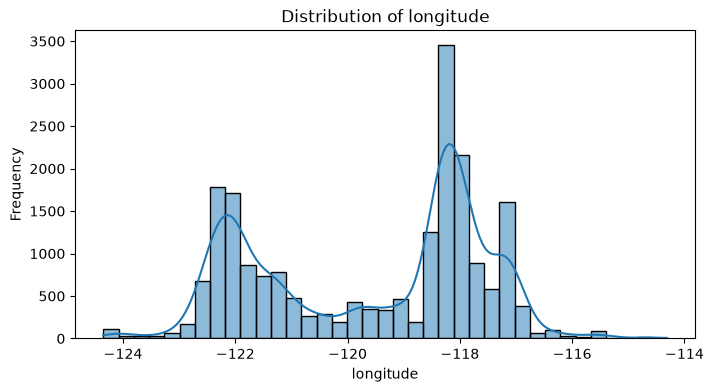

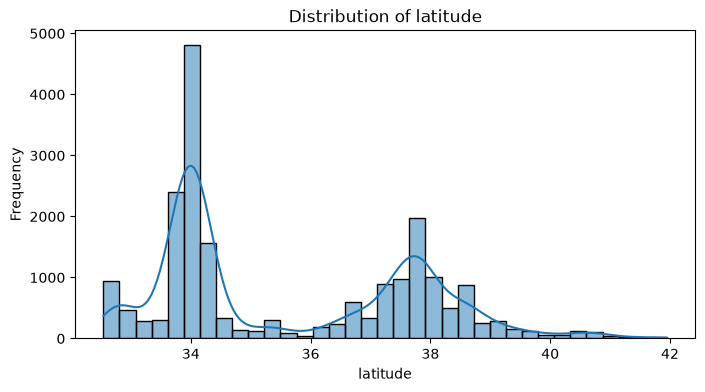

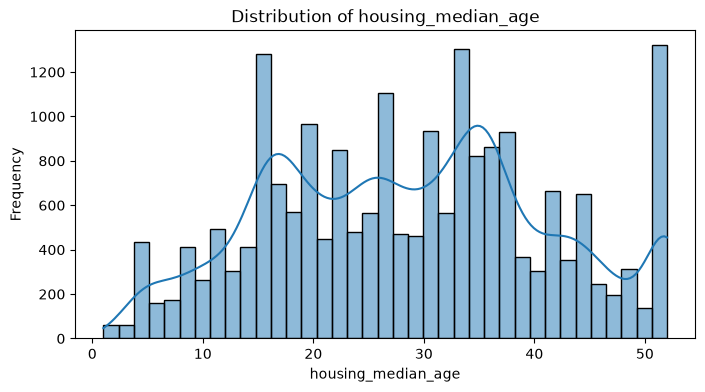

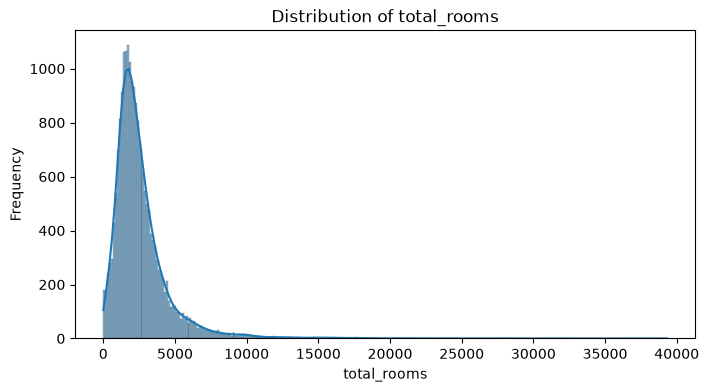

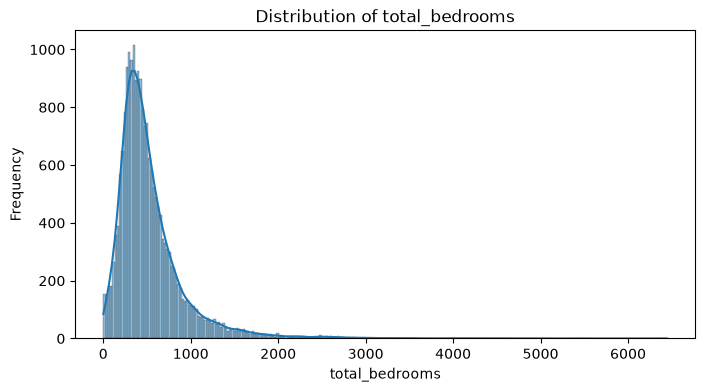

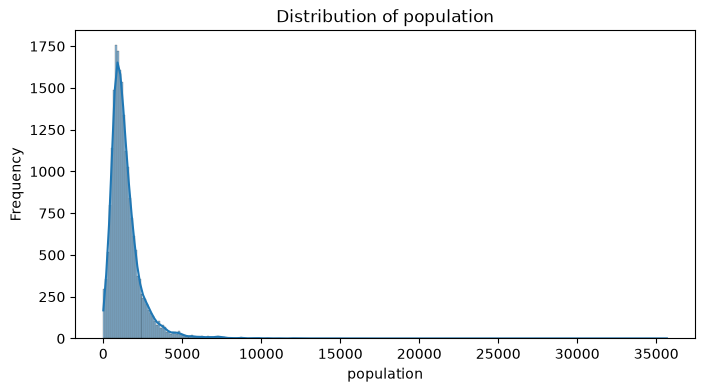

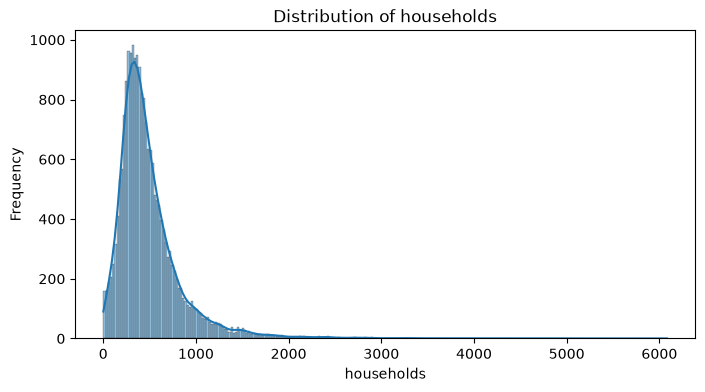

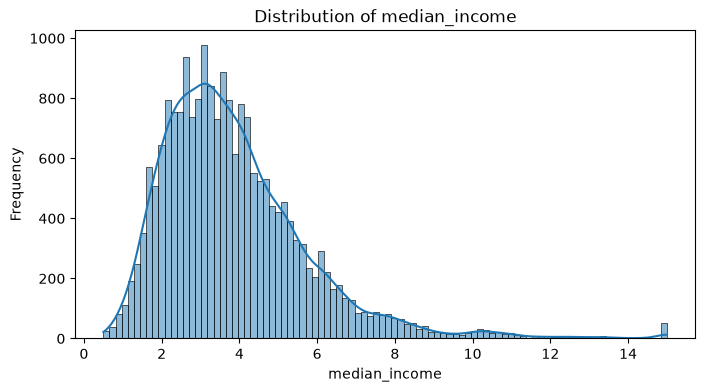

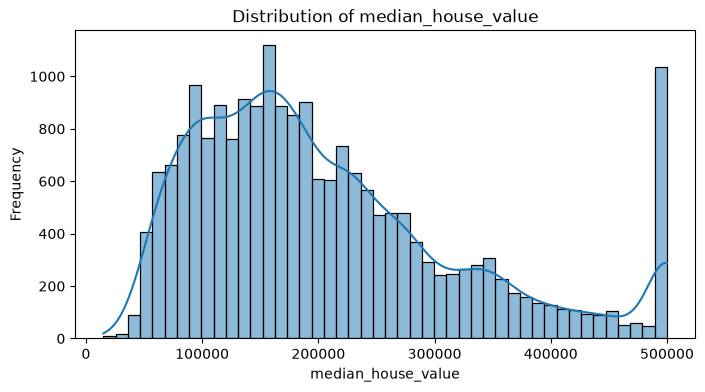

In [7]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

## 8. Boxplots for Outlier Inspection

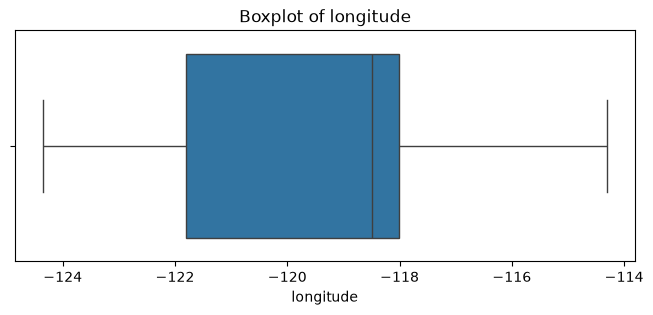

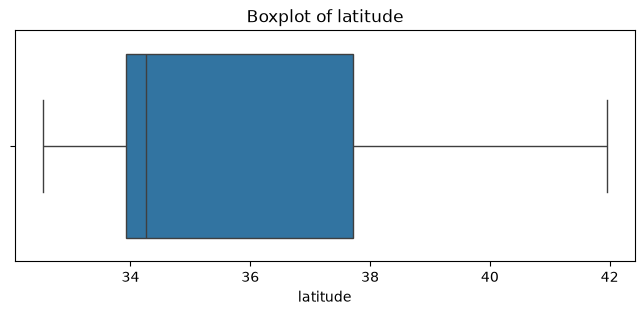

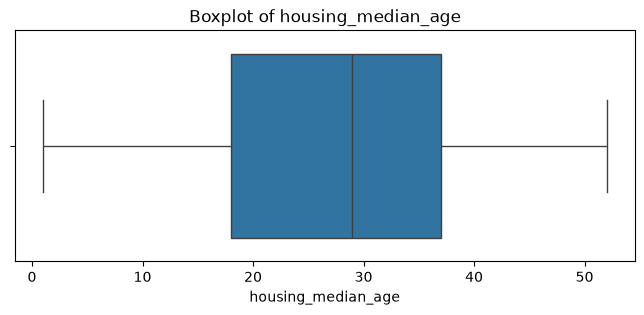

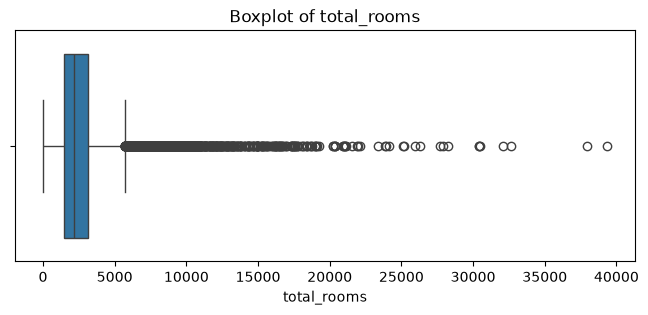

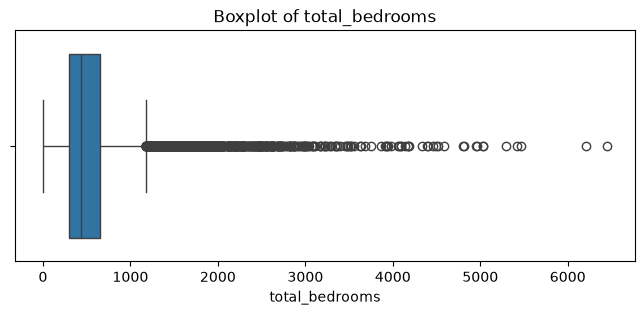

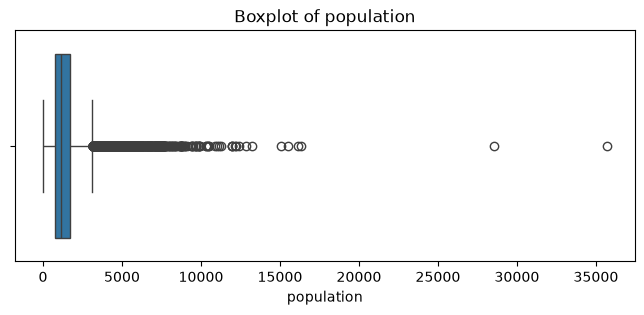

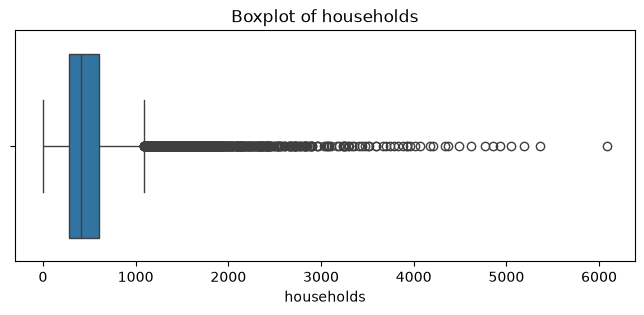

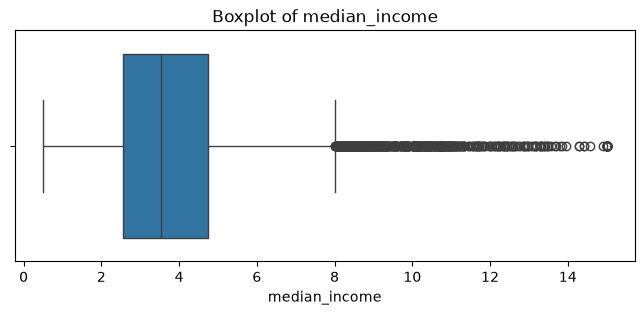

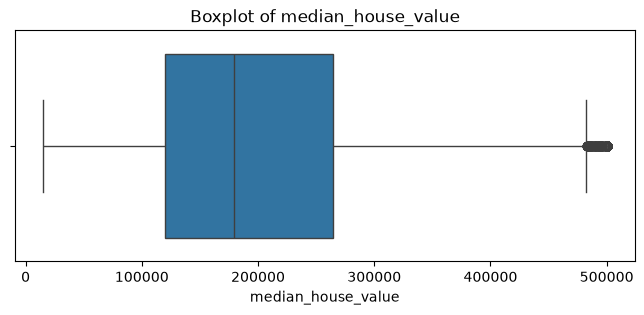

In [8]:
for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

## 9. Categorical Feature Analysis

In [9]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for column in categorical_columns:
    print(f'\Value counts for {column}:')
    display(df[column].value_counts(dropna=False))

\Value counts for ocean_proximity:


<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\irukagae\AppData\Local\Temp\ipykernel_5544\3704362754.py:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  print(f'\Value counts for {column}:')
C:\Users\irukagae\AppData\Local\Temp\ipykernel_5544\3704362754.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

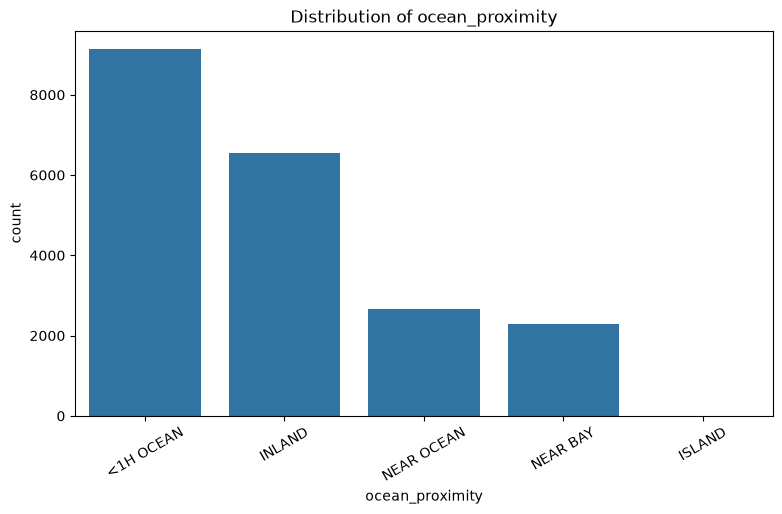

In [10]:
for column in categorical_columns:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=30)
    plt.show()

## 10. Correlation Analysis

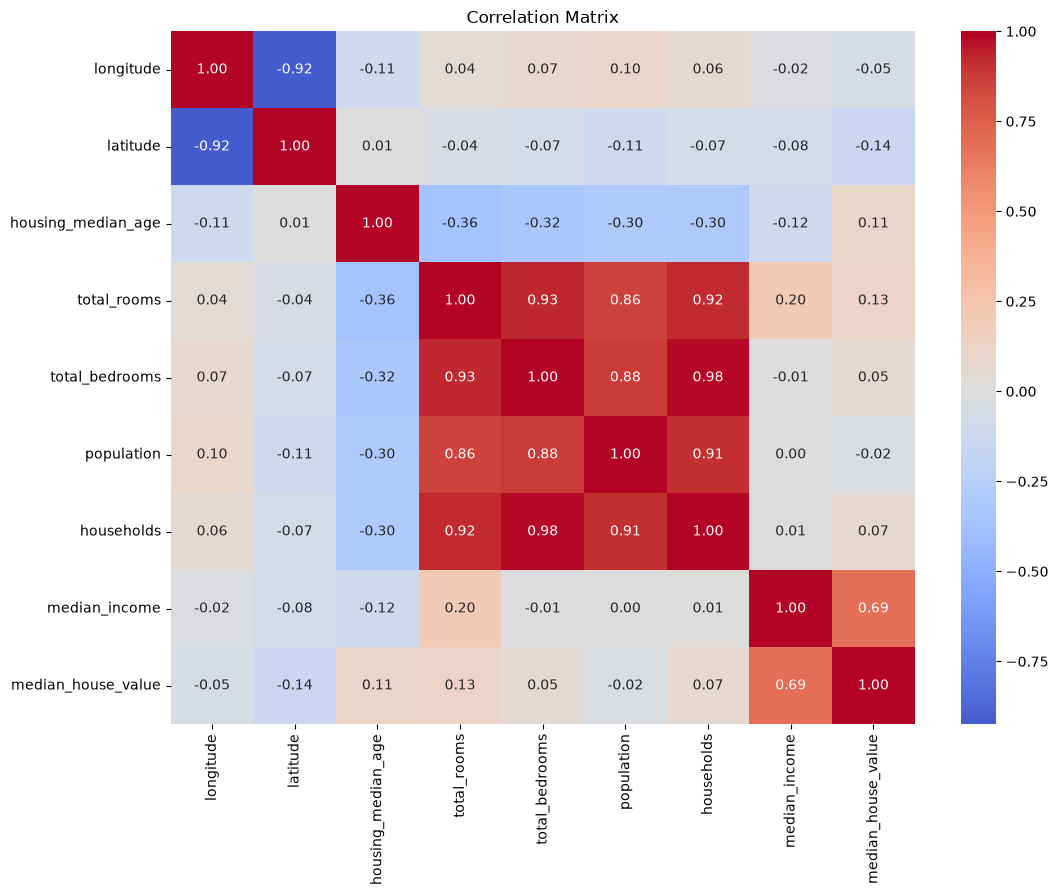

In [11]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

## 11. Correlation with Target Variable

In [12]:
target_correlation = correlation_matrix['median_house_value'].sort_values(ascending=False)
display(target_correlation)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## 12. Relationship Between Features and Target

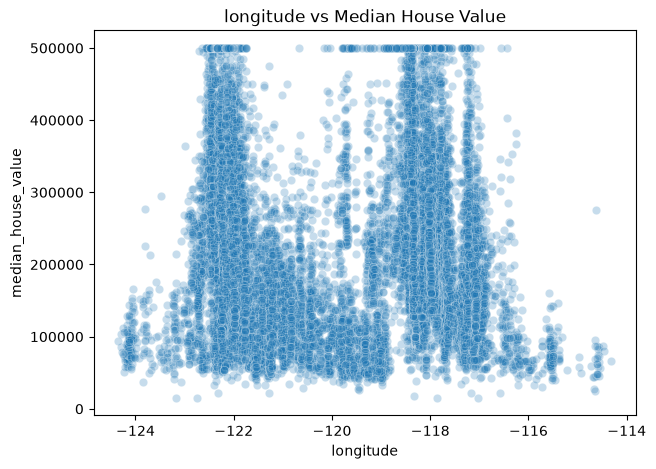

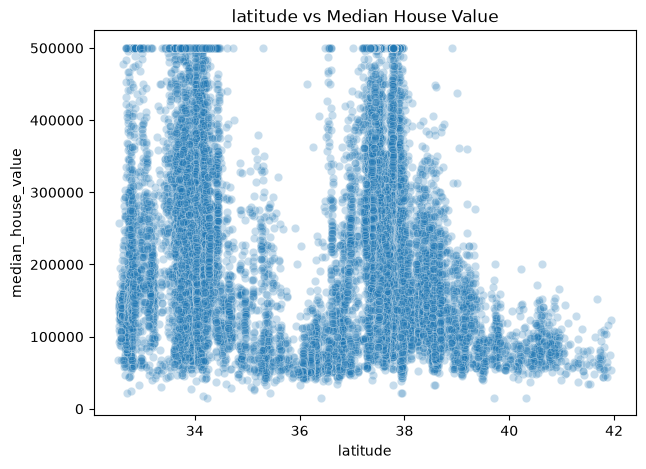

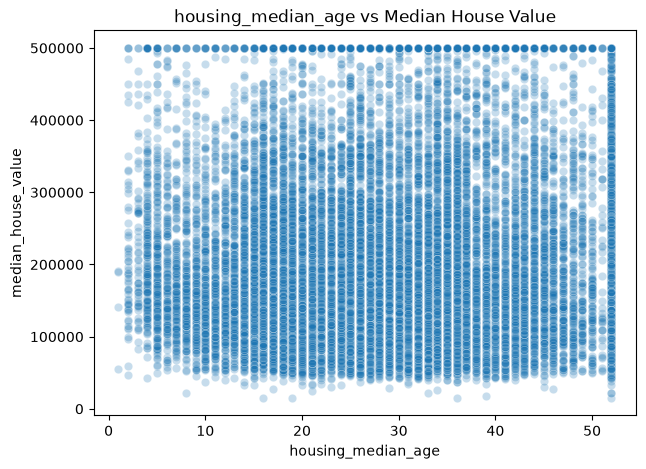

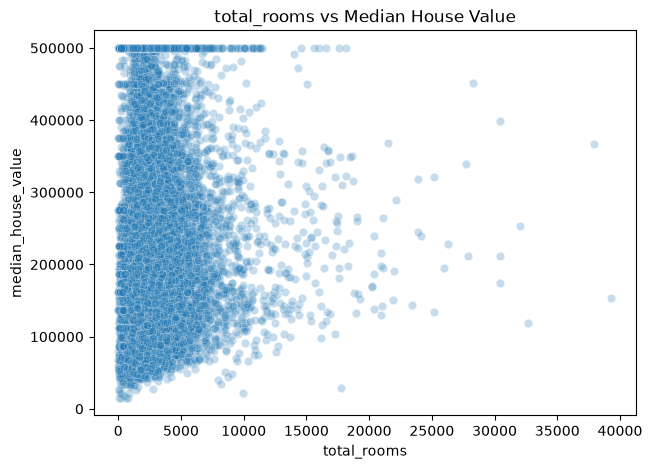

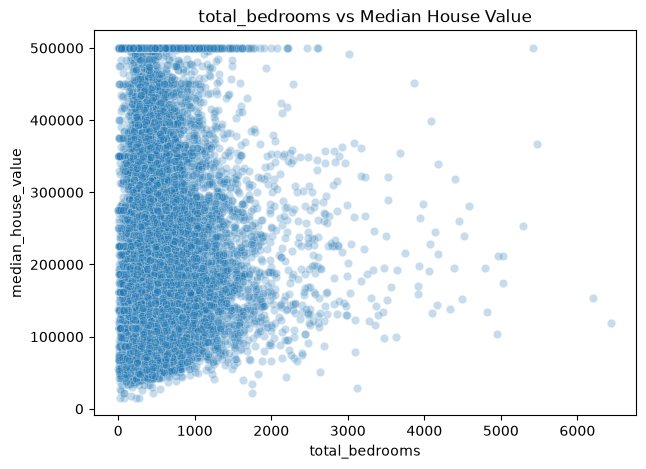

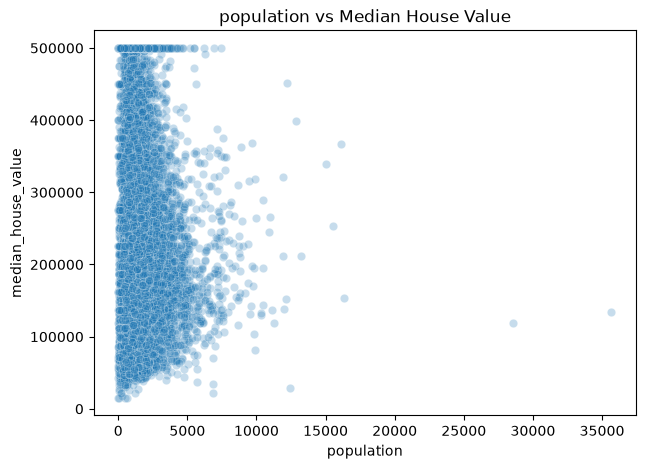

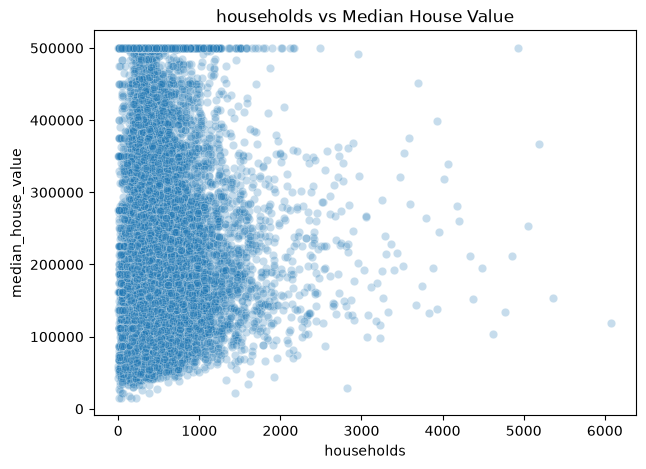

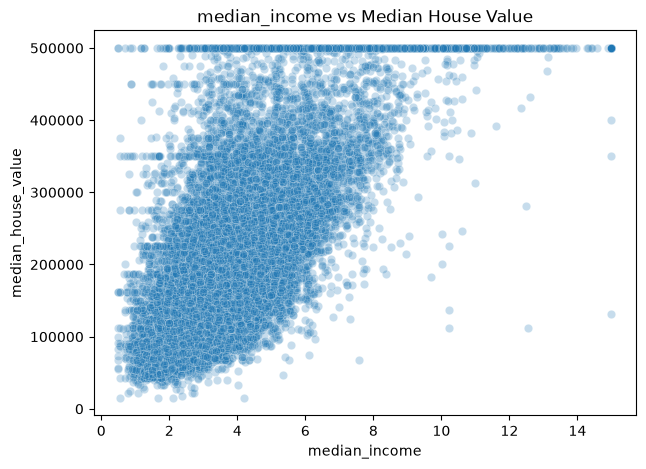

In [13]:
for column in numeric_columns.drop('median_house_value'):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=column, y='median_house_value', alpha=0.25)
    plt.title(f'{column} vs Median House Value')
    plt.show()

## 13. Median House Value by Ocean Proximity

In [14]:
display(
    df.groupby('ocean_proximity')['median_house_value']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .sort_values('median', ascending=False)
)

,count,mean,median,std,min,max
ocean_proximity,,,,,,
ISLAND,5,380440.000000,414700.0,80559.561816,287500.0,450000.0
NEAR BAY,2290,259212.311790,233800.0,122818.537064,22500.0,500001.0
NEAR OCEAN,2658,249433.977427,229450.0,122477.145927,22500.0,500001.0
<1H OCEAN,9136,240084.285464,214850.0,106124.292213,17500.0,500001.0
INLAND,6551,124805.392001,108500.0,70007.908494,14999.0,500001.0


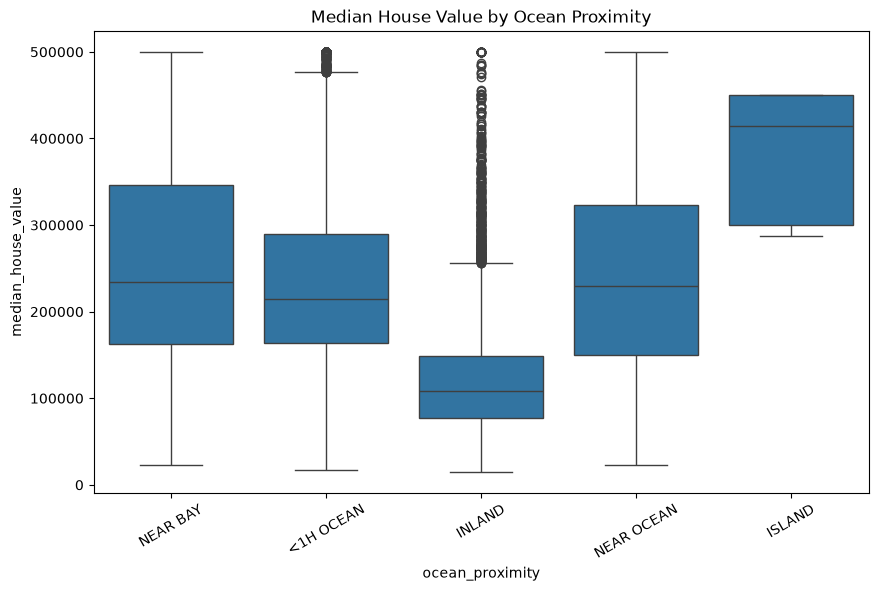

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value')
plt.title('Median House Value by Ocean Proximity')
plt.xticks(rotation=30)
plt.show()

## 14. Geographic Distribution

Longitude and latitude are used to visualize the geographic distribution of observations and their relationship with house value.

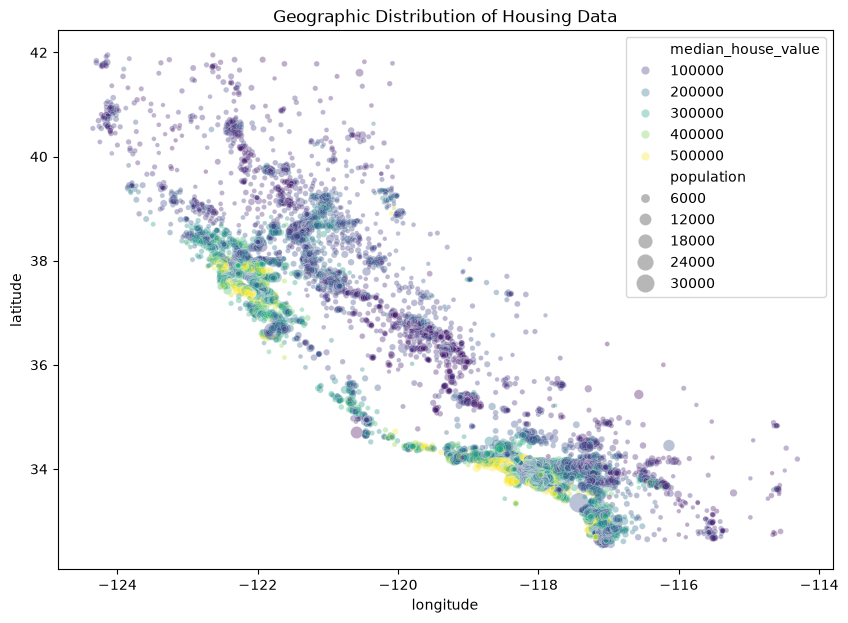

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    size='population',
    sizes=(10, 200),
    alpha=0.35,
    palette='viridis'
)
plt.title('Geographic Distribution of Housing Data')
plt.show()